In [1]:
# ==========================================================
# STUDENT 2
# NOTEBOOK 03
# BERT FINE-TUNING
# ==========================================================

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ==========================================================
# PROJECT CONFIGURATION
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

PROCESSED_DATA = (
    PROJECT_ROOT /
    "datasets" /
    "processed"
)

MODELS = PROJECT_ROOT / "models"

MODELS.mkdir(exist_ok=True)

print("="*70)
print("PROJECT CONFIGURATION")
print("="*70)

print("Device :", device)
print("Processed Data :", PROCESSED_DATA)

PROJECT CONFIGURATION
Device : cpu
Processed Data : C:\Users\DELL\Documents\Email_Phishing_Project\datasets\processed


In [3]:
# ==========================================================
# LOAD SUBSETS
# ==========================================================

train_df = pd.read_csv(
    PROCESSED_DATA /
    "bert_train_subset.csv"
)

validation_df = pd.read_csv(
    PROCESSED_DATA /
    "bert_validation_subset.csv"
)

test_df = pd.read_csv(
    PROCESSED_DATA /
    "bert_test_subset.csv"
)

print("="*70)
print("DATASETS LOADED")
print("="*70)

print("Training :", len(train_df))
print("Validation :", len(validation_df))
print("Testing :", len(test_df))

DATASETS LOADED
Training : 5000
Validation : 1000
Testing : 1000


In [4]:
# ==========================================================
# MISSING VALUES
# ==========================================================

print("="*70)
print("MISSING VALUES")
print("="*70)

print(train_df.isnull().sum())

MISSING VALUES
dataset                 0
subject               152
body                    1
email_text              0
label                   0
cleaned_email_text      0
email_length            0
dtype: int64


In [5]:
# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

distribution = train_df["label"].value_counts()

percentage = (
    train_df["label"]
    .value_counts(normalize=True)
    *100
).round(2)

summary = pd.DataFrame({

    "Count": distribution,

    "Percentage": percentage

})

summary

,Count,Percentage
label,,
0,4552,91.04
1,448,8.96


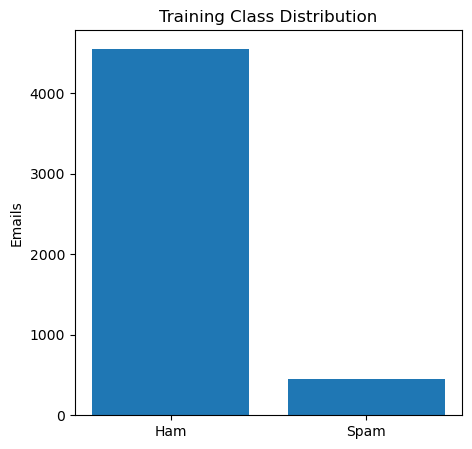

In [6]:
plt.figure(figsize=(5,5))

plt.bar(

    ["Ham","Spam"],

    distribution.sort_index()

)

plt.title("Training Class Distribution")

plt.ylabel("Emails")

plt.show()

In [7]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")

Tokenizer loaded.


In [8]:
# ==========================================================
# TOKEN LENGTH ANALYSIS
# ==========================================================

token_lengths = []

for text in train_df["cleaned_email_text"]:

    tokens = tokenizer.encode(
        str(text),
        add_special_tokens=True
    )

    token_lengths.append(len(tokens))

train_df["token_length"] = token_lengths

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1878 > 512). Running this sequence through the model will result in indexing errors


In [9]:
print("="*70)
print("TOKEN LENGTH STATISTICS")
print("="*70)

print(

    train_df["token_length"]

    .describe()

)

TOKEN LENGTH STATISTICS
count      5000.000000
mean        507.528200
std        2151.883988
min           3.000000
25%          82.000000
50%         222.000000
75%         493.000000
max      117174.000000
Name: token_length, dtype: float64


In [10]:
MAX_LENGTH = 512

long_emails = (

    train_df["token_length"]

    > MAX_LENGTH

).sum()

percentage = (

    long_emails

    / len(train_df)

    *100

)

print("="*70)
print("TRUNCATION ANALYSIS")
print("="*70)

print("Emails >512 tokens :", long_emails)

print(f"Percentage : {percentage:.2f}%")

TRUNCATION ANALYSIS
Emails >512 tokens : 1201
Percentage : 24.02%


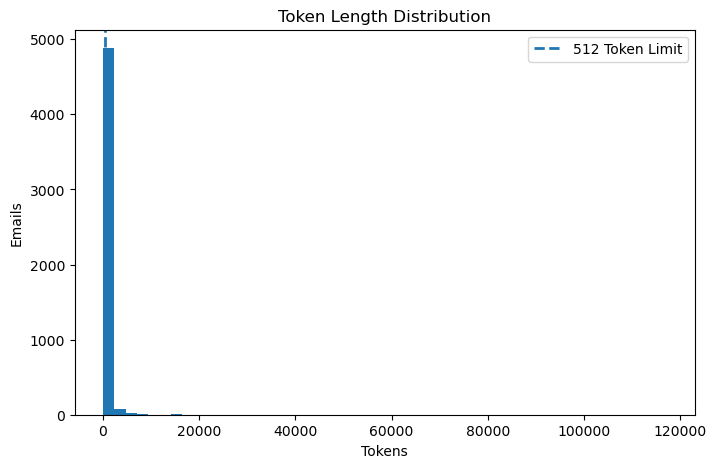

In [11]:
plt.figure(figsize=(8,5))

plt.hist(

    train_df["token_length"],

    bins=50

)

plt.axvline(

    512,

    linestyle="--",

    linewidth=2,

    label="512 Token Limit"

)

plt.legend()

plt.title("Token Length Distribution")

plt.xlabel("Tokens")

plt.ylabel("Emails")

plt.show()

In [12]:
# ==========================================================
# CLASS-WEIGHTED LOSS
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float
).to(device)

criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

print("=" * 70)
print("CLASS WEIGHTS")
print("=" * 70)

for c, w in zip(classes, weights):
    print(f"Class {c}: {w:.4f}")

CLASS WEIGHTS
Class 0: 0.5492
Class 1: 5.5804


In [13]:
# ==========================================================
# LOAD TOKENIZER
# ==========================================================

from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("=" * 70)
print("TOKENIZER LOADED")
print("=" * 70)
print("Vocabulary Size:", tokenizer.vocab_size)

TOKENIZER LOADED
Vocabulary Size: 30522


In [14]:
# ==========================================================
# EMAIL DATASET
# ==========================================================

from torch.utils.data import Dataset

MAX_LENGTH = 512

class EmailDataset(Dataset):

    def __init__(self, dataframe, tokenizer):

        self.data = dataframe.reset_index(drop=True)

        self.tokenizer = tokenizer

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        text = str(
            self.data.loc[idx, "cleaned_email_text"]
        )

        label = int(
            self.data.loc[idx, "label"]
        )

        encoding = self.tokenizer(

            text,

            truncation=True,

            max_length=MAX_LENGTH,

            padding=False,      # Dynamic padding

            return_tensors="pt"

        )

        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(label, dtype=torch.long)

        }

In [15]:
train_dataset = EmailDataset(
    train_df,
    tokenizer
)

validation_dataset = EmailDataset(
    validation_df,
    tokenizer
)

test_dataset = EmailDataset(
    test_df,
    tokenizer
)

print("Datasets created successfully.")

Datasets created successfully.


In [16]:
# ==========================================================
# DATA COLLATOR
# ==========================================================

from transformers import DataCollatorWithPadding

collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [17]:
# ==========================================================
# DATALOADERS
# ==========================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8      # Recommended for CPU

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collator

)

validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collator

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collator

)

print("="*70)
print("DATALOADERS CREATED")
print("="*70)
print("Batch Size:", BATCH_SIZE)

DATALOADERS CREATED
Batch Size: 8


In [18]:
batch = next(iter(train_loader))

print("="*70)
print("BATCH INFORMATION")
print("="*70)

for key, value in batch.items():

    print(key)

    print(value.shape)

    print()

BATCH INFORMATION
input_ids
torch.Size([8, 512])

attention_mask
torch.Size([8, 512])

labels
torch.Size([8])



In [19]:
# ==========================================================
# LOAD PRETRAINED BERT
# ==========================================================

from transformers import AutoModelForSequenceClassification

NUM_LABELS = 2

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

model = model.to(device)

print("=" * 70)
print("MODEL LOADED")
print("=" * 70)
print(model.__class__.__name__)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


MODEL LOADED
BertForSequenceClassification


In [20]:
# ==========================================================
# CLASS WEIGHTS
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df["label"])

weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=train_df["label"]

)

class_weights = torch.tensor(
    weights,
    dtype=torch.float
).to(device)

print("=" * 70)
print("CLASS WEIGHTS")
print("=" * 70)

for c, w in zip(classes, weights):

    print(f"Class {c}: {w:.4f}")

CLASS WEIGHTS
Class 0: 0.5492
Class 1: 5.5804


In [21]:
# ==========================================================
# LOSS AND OPTIMIZER
# ==========================================================

from torch.optim import AdamW

criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

print("=" * 70)
print("TRAINING COMPONENTS READY")
print("=" * 70)
print("Loss Function :", criterion)
print("Learning Rate :", 2e-5)

TRAINING COMPONENTS READY
Loss Function : CrossEntropyLoss()
Learning Rate : 2e-05


In [22]:
# ==========================================================
# TRAINING CONFIGURATION
# ==========================================================

from transformers import get_linear_schedule_with_warmup

EPOCHS = 3

total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=int(0.1 * total_training_steps),

    num_training_steps=total_training_steps

)

print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)

print("Epochs :", EPOCHS)
print("Training Steps :", total_training_steps)
print("Warmup Steps :", int(0.1 * total_training_steps))

TRAINING CONFIGURATION
Epochs : 3
Training Steps : 1875
Warmup Steps : 187


In [23]:
# ==========================================================
# TRAINING FUNCTION
# ==========================================================

from tqdm import tqdm

def train_epoch(model, dataloader):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for batch in tqdm(dataloader, desc="Training"):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        logits = outputs.logits

        loss = criterion(logits, labels)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0

        )

        optimizer.step()

        scheduler.step()

        running_loss += loss.item()

        predictions = torch.argmax(

            logits,

            dim=1

        )

        correct += (

            predictions == labels

        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [24]:
# ==========================================================
# VALIDATION FUNCTION
# ==========================================================

def evaluate(model, dataloader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    predictions_all = []

    labels_all = []

    with torch.no_grad():

        for batch in tqdm(dataloader, desc="Validation"):

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            labels = batch["labels"].to(device)

            outputs = model(

                input_ids=input_ids,

                attention_mask=attention_mask

            )

            logits = outputs.logits

            loss = criterion(logits, labels)

            running_loss += loss.item()

            predictions = torch.argmax(

                logits,

                dim=1

            )

            predictions_all.extend(

                predictions.cpu().numpy()

            )

            labels_all.extend(

                labels.cpu().numpy()

            )

            correct += (

                predictions == labels

            ).sum().item()

            total += labels.size(0)

    loss = running_loss / len(dataloader)

    accuracy = correct / total

    return (

        loss,

        accuracy,

        predictions_all,

        labels_all

    )

In [25]:
# ==========================================================
# EARLY STOPPING
# ==========================================================

best_validation_loss = float("inf")

patience = 2

counter = 0

history = {

    "train_loss": [],

    "validation_loss": [],

    "train_accuracy": [],

    "validation_accuracy": []

}

In [26]:
# ==========================================================
# TRAINING LOOP
# ==========================================================

for epoch in range(EPOCHS):

    print("\n")

    print("=" * 70)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print("=" * 70)

    train_loss, train_accuracy = train_epoch(

        model,

        train_loader

    )

    validation_loss, validation_accuracy, _, _ = evaluate(

        model,

        validation_loader

    )

    history["train_loss"].append(train_loss)

    history["validation_loss"].append(validation_loss)

    history["train_accuracy"].append(train_accuracy)

    history["validation_accuracy"].append(validation_accuracy)

    print(f"Train Loss       : {train_loss:.4f}")
    print(f"Train Accuracy   : {train_accuracy:.4f}")

    print(f"Validation Loss  : {validation_loss:.4f}")
    print(f"Validation Accuracy : {validation_accuracy:.4f}")

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        counter = 0

        torch.save(

            model.state_dict(),

            MODELS /

            "best_bert_model.pt"

        )

        print("✓ Best model saved.")

    else:

        counter += 1

        print(f"No improvement ({counter}/{patience})")

        if counter >= patience:

            print("Early stopping triggered.")

            break



Epoch 1/3


Validation: 100%|████████████████████████████████████████████████████████████████████| 125/125 [17:07<00:00,  8.22s/it]


Train Loss       : 0.3139
Train Accuracy   : 0.9462
Validation Loss  : 0.1785
Validation Accuracy : 0.9900
✓ Best model saved.


Epoch 2/3


Validation: 100%|████████████████████████████████████████████████████████████████████| 125/125 [17:14<00:00,  8.27s/it]


Train Loss       : 0.0842
Train Accuracy   : 0.9938
Validation Loss  : 0.2005
Validation Accuracy : 0.9930
No improvement (1/2)


Epoch 3/3


Validation: 100%|████████████████████████████████████████████████████████████████████| 125/125 [17:29<00:00,  8.40s/it]


Train Loss       : 0.0312
Train Accuracy   : 0.9984
Validation Loss  : 0.1596
Validation Accuracy : 0.9910
✓ Best model saved.


In [27]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": epoch + 1,
        "history": history,
        "class_weights": class_weights
    },
    MODELS / "bert_checkpoint.pt"
)